In [201]:
import pandas as pd
import numpy as np
import missingno as msno
import seaborn as sns
from phik import resources, report
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

### **1. Загрузка данных и описание**

In [202]:
housing = fetch_california_housing()

In [203]:
housing

{'data': array([[   8.3252    ,   41.        ,    6.98412698, ...,    2.55555556,
           37.88      , -122.23      ],
        [   8.3014    ,   21.        ,    6.23813708, ...,    2.10984183,
           37.86      , -122.22      ],
        [   7.2574    ,   52.        ,    8.28813559, ...,    2.80225989,
           37.85      , -122.24      ],
        ...,
        [   1.7       ,   17.        ,    5.20554273, ...,    2.3256351 ,
           39.43      , -121.22      ],
        [   1.8672    ,   18.        ,    5.32951289, ...,    2.12320917,
           39.43      , -121.32      ],
        [   2.3886    ,   16.        ,    5.25471698, ...,    2.61698113,
           39.37      , -121.24      ]], shape=(20640, 8)),
 'target': array([4.526, 3.585, 3.521, ..., 0.923, 0.847, 0.894], shape=(20640,)),
 'frame': None,
 'target_names': ['MedHouseVal'],
 'feature_names': ['MedInc',
  'HouseAge',
  'AveRooms',
  'AveBedrms',
  'Population',
  'AveOccup',
  'Latitude',
  'Longitude'],
 'DESCR': 

In [204]:
print(fetch_california_housing().DESCR)

.. _california_housing_dataset:

California Housing dataset
--------------------------

**Data Set Characteristics:**

:Number of Instances: 20640

:Number of Attributes: 8 numeric, predictive attributes and the target

:Attribute Information:
    - MedInc        median income in block group
    - HouseAge      median house age in block group
    - AveRooms      average number of rooms per household
    - AveBedrms     average number of bedrooms per household
    - Population    block group population
    - AveOccup      average number of household members
    - Latitude      block group latitude
    - Longitude     block group longitude

:Missing Attribute Values: None

This dataset was obtained from the StatLib:
https://lib.stat.cmu.edu/datasets/houses.zip

The target variable is the median house value for California districts,
expressed in hundreds of thousands of dollars ($100,000).

This dataset was derived from the 1990 U.S. census, using one row per census
block group. A block g

In [205]:
df = pd.DataFrame(housing.data, columns=housing.feature_names)

In [206]:
df['MedHouseVal'] = housing.target

In [207]:
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [208]:
df.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


In [209]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


В данных отсутствуют пропуски

### **2. Построение модели**

In [210]:
X = df[['MedInc','HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']]

In [211]:
y = df['MedHouseVal']

In [212]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [213]:
model = LinearRegression()
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](8,)","[ 0.45, 0.01,-0.12,...,-0. ,-0.42,-0.43]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](8,)","['MedInc','HouseAge','AveRooms',...,'AveOccup','Latitude','Longitude']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-37.02
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,8
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,8


In [214]:
y_train_pred = model.predict(X_train)

In [215]:
y_test_pred = model.predict(X_test)

In [216]:
rmse_train = np.sqrt(mean_squared_error(y_train, y_train_pred))
r2_train = r2_score(y_train, y_train_pred)

In [217]:
rmse_test = np.sqrt(mean_squared_error(y_test, y_test_pred))
r2_test = r2_score(y_test, y_test_pred)

In [218]:
print("ОБУЧАЮЩАЯ ВЫБОРКА (Train):")
print(f"  RMSE: {rmse_train}")
print(f"  R²:   {r2_train}")
print(f"  MSE:  {mean_squared_error(y_train, y_train_pred):.4f}")
print("ТЕСТОВАЯ ВЫБОРКА (Train):")
print(f"  RMSE: {rmse_test}")
print(f"  R²:   {r2_test}")
print(f"  MSE:  {mean_squared_error(y_test, y_test_pred):.4f}")

ОБУЧАЮЩАЯ ВЫБОРКА (Train):
  RMSE: 0.7196757085831575
  R²:   0.6125511913966952
  MSE:  0.5179
ТЕСТОВАЯ ВЫБОРКА (Train):
  RMSE: 0.7455813830127763
  R²:   0.575787706032451
  MSE:  0.5559


Была построена модель и получены метрики RMSE, R2 на обучающем и тестовом множестве

### **3. Распределение целевой переменной**

In [219]:
def diagnose_distribution(df, col):
  fig, axes = plt.subplots(1, 2, figsize=(12, 5))

  # --- График 1: Нормальное распределение ---
  sns.histplot(df[col], kde=True, color='teal', ax=axes[0], alpha=0.6)
  mean_h = df[col].mean()
  median_h = df[col].median()

  # Линии среднего и медианы
  axes[0].axvline(mean_h, color='red', linestyle='--', linewidth=2, label=f'Mean: {mean_h:.1f}')
  axes[0].axvline(median_h, color='yellow', linestyle='-', linewidth=2, label=f'Median: {median_h:.1f}')
  axes[0].set_title('Гистограмма', fontsize=14, fontweight='bold')
  axes[0].legend()

  # Boxplot
  sns.boxplot(x=df[col], ax=axes[1], color='cyan')
  axes[1].set_title(f'Boxplot', fontsize=14, fontweight='bold')

  plt.suptitle(f'Распределение: {col}', fontsize=16, fontweight='bold', y=1.05)
  plt.tight_layout()
  plt.show()

  # Численные метрики
  skew = df[col].skew()
  kurt = df[col].kurt()

  print(f"--- МЕТРИКИ ДЛЯ {col.upper()} ---")
  print(f"Skewness (Скос): {skew:.4f} (Идеал = 0.0)")
  print(f"Kurtosis (Острота пика): {kurt:.4f} (Идеал = 0.0)")

  if abs(skew) < 0.5:
      print("✅ Вердикт: Похоже на нормальное распределение.")
  elif abs(skew) > 1:
      print("⚠️ Вердикт: Сильный перекос")
  else:
      print("ℹ️ Вердикт: Умеренный перекос.")
  print("-" * 30)

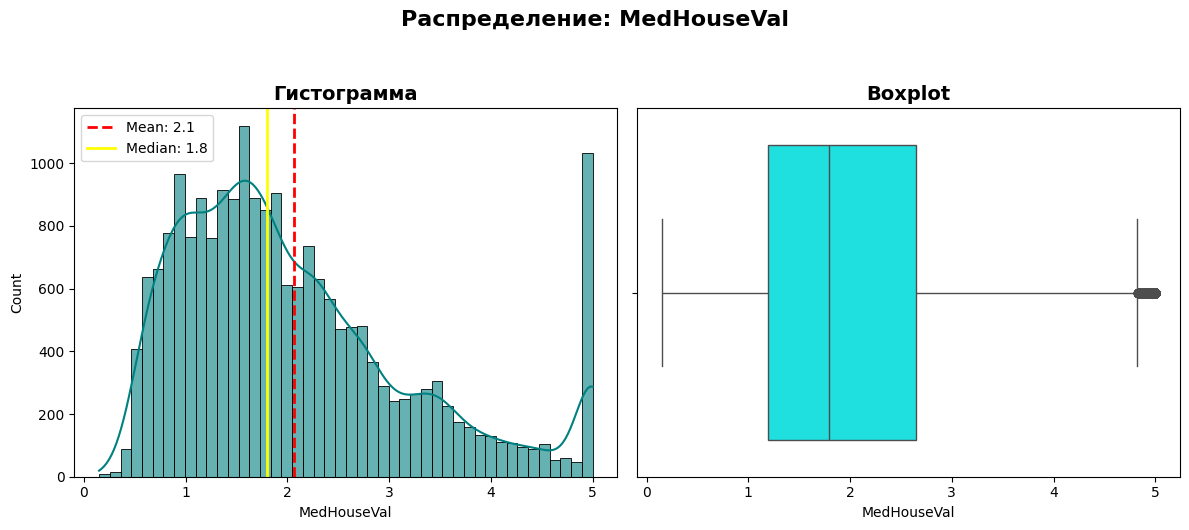

--- МЕТРИКИ ДЛЯ MEDHOUSEVAL ---
Skewness (Скос): 0.9778 (Идеал = 0.0)
Kurtosis (Острота пика): 0.3279 (Идеал = 0.0)
ℹ️ Вердикт: Умеренный перекос.
------------------------------


In [220]:
diagnose_distribution(df, 'MedHouseVal')

Имеется перекос с правую сторону и наличие выбросов

### **4. Построение матрицы корреляций**

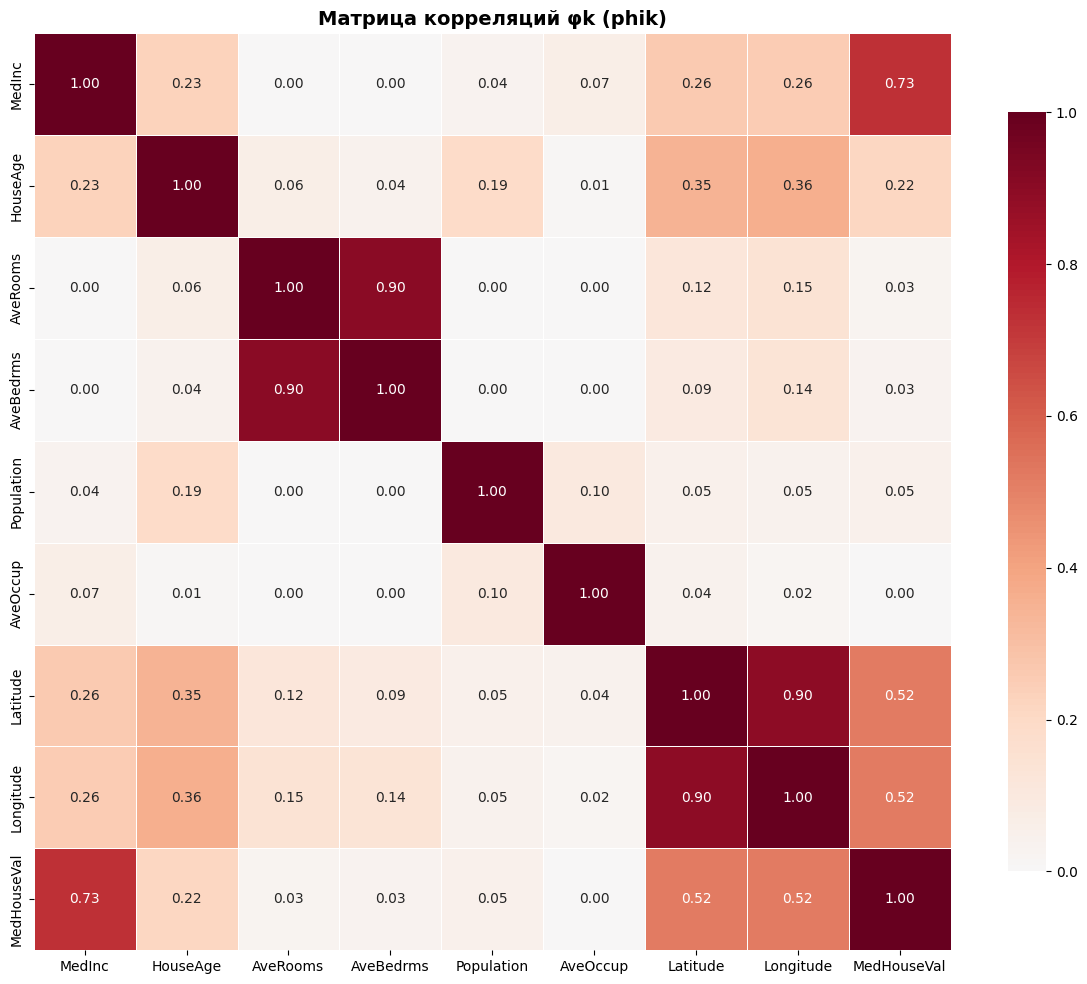

In [221]:
# Определяем интервальные (непрерывные) переменные
interval_cols = ['MedInc',
    'HouseAge',
    'AveRooms',
    'AveBedrms',
    'Population',
    'AveOccup',
    'Latitude',
    'Longitude',
    'MedHouseVal'
    ]

# Расчёт матрицы phik с явным указанием интервальных переменных
phik_matrix = df.phik_matrix(interval_cols=interval_cols, )

# Heatmap
fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(phik_matrix, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            square=True, linewidths=0.5, ax=ax, cbar_kws={'shrink': 0.8})
ax.set_title('Матрица корреляций φk (phik)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

Была построена матрица корреляции с методом phik.

У целевой переменной MedHouseVal имеется корреляция с переменными: MedInc, HouseAge, Latitude, Longitude

Переменные с низкой корреляцией можно удалить

### **5. Удаление лишних колонок и построение модели**

In [222]:
df2 = df.copy()

In [223]:
df2

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422
...,...,...,...,...,...,...,...,...,...
20635,1.5603,25.0,5.045455,1.133333,845.0,2.560606,39.48,-121.09,0.781
20636,2.5568,18.0,6.114035,1.315789,356.0,3.122807,39.49,-121.21,0.771
20637,1.7000,17.0,5.205543,1.120092,1007.0,2.325635,39.43,-121.22,0.923
20638,1.8672,18.0,5.329513,1.171920,741.0,2.123209,39.43,-121.32,0.847


In [224]:
df2 = df2.drop(['AveRooms','AveBedrms','Population','AveOccup'], axis = 1)

In [225]:
X2 = df2[['MedInc', 'HouseAge', 'Latitude', 'Longitude']]

In [226]:
y2 = df2['MedHouseVal']

In [227]:
X2_train, X2_test, y2_train, y2_test = train_test_split(X2, y2, test_size=0.2, random_state=42)

In [228]:
model2 = LinearRegression()
model2.fit(X2_train, y2_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](4,)","[ 0.38, 0.01,-0.44,-0.45]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](4,)","['MedInc','HouseAge','Latitude','Longitude']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-37.66
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,4
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,4


In [229]:
y2_train_pred = model2.predict(X2_train)

In [230]:
y2_test_pred = model2.predict(X2_test)

In [231]:
print("ОБУЧАЮЩАЯ ВЫБОРКА (Train):")
print(f"  RMSE: {np.sqrt(mean_squared_error(y2_train, y2_train_pred))}")
print(f"  R²:   {r2_score(y2_train, y2_train_pred)}")
print(f"  MSE:  {mean_squared_error(y2_train, y2_train_pred):.4f}")
print("ТЕСТОВАЯ ВЫБОРКА (Train):")
print(f"  RMSE: {np.sqrt(mean_squared_error(y2_test, y2_test_pred))}")
print(f"  R²:   {r2_score(y2_test, y2_test_pred)}")
print(f"  MSE:  {mean_squared_error(y2_test, y2_test_pred):.4f}")

ОБУЧАЮЩАЯ ВЫБОРКА (Train):
  RMSE: 0.7338291983766804
  R²:   0.5971618271146777
  MSE:  0.5385
ТЕСТОВАЯ ВЫБОРКА (Train):
  RMSE: 0.7409322235939553
  R²:   0.5810616616067165
  MSE:  0.5490


### **6. Исследование признаков на выбросы**

Вернёмся к изначальному датафрему и првоерим распределение данных

In [232]:
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


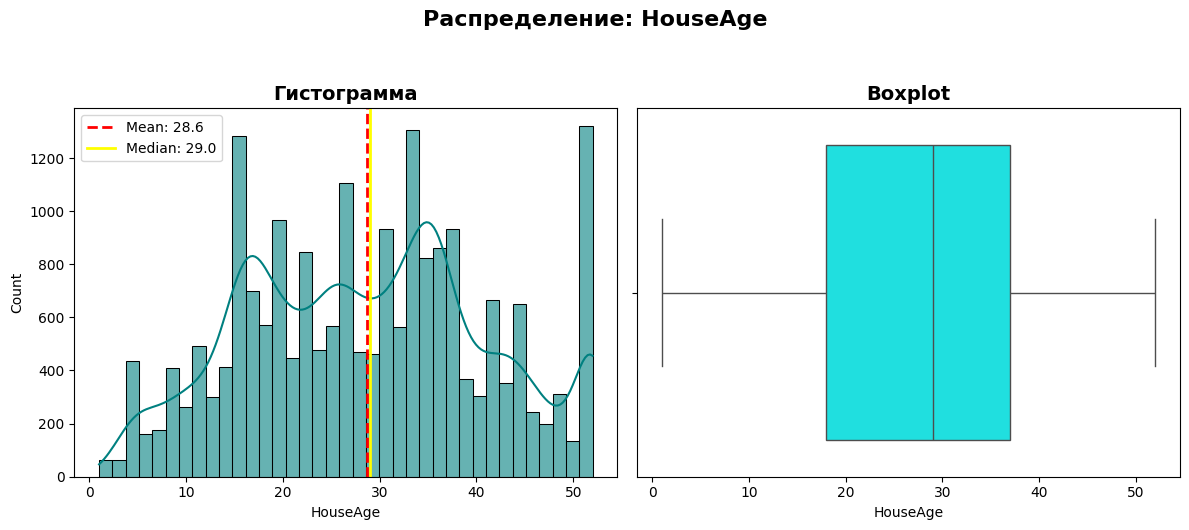

--- МЕТРИКИ ДЛЯ HOUSEAGE ---
Skewness (Скос): 0.0603 (Идеал = 0.0)
Kurtosis (Острота пика): -0.8006 (Идеал = 0.0)
✅ Вердикт: Похоже на нормальное распределение.
------------------------------


In [233]:
diagnose_distribution(df, 'HouseAge')

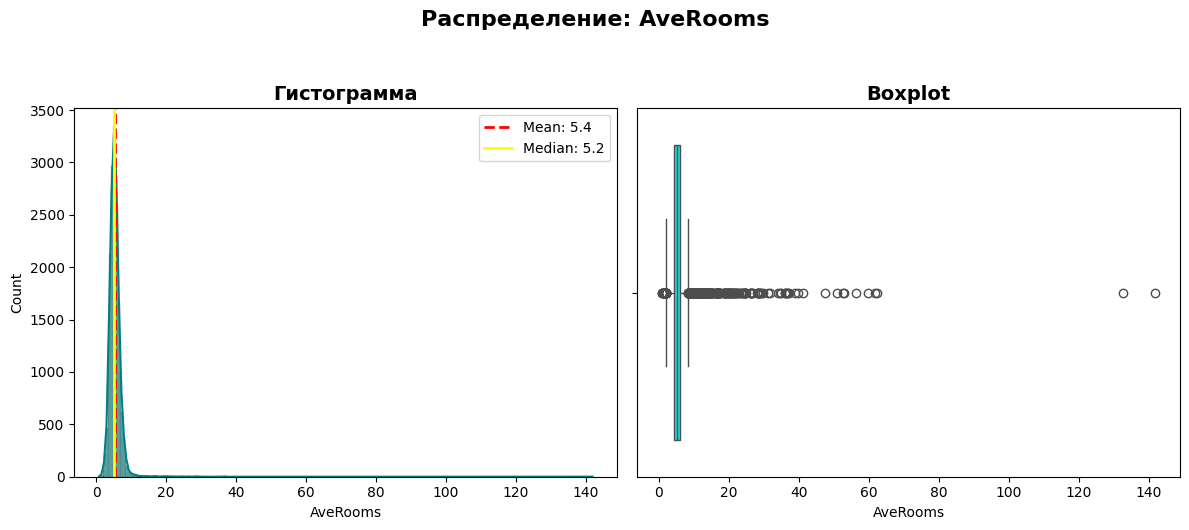

--- МЕТРИКИ ДЛЯ AVEROOMS ---
Skewness (Скос): 20.6979 (Идеал = 0.0)
Kurtosis (Острота пика): 879.3533 (Идеал = 0.0)
⚠️ Вердикт: Сильный перекос
------------------------------


In [234]:
diagnose_distribution(df, 'AveRooms')

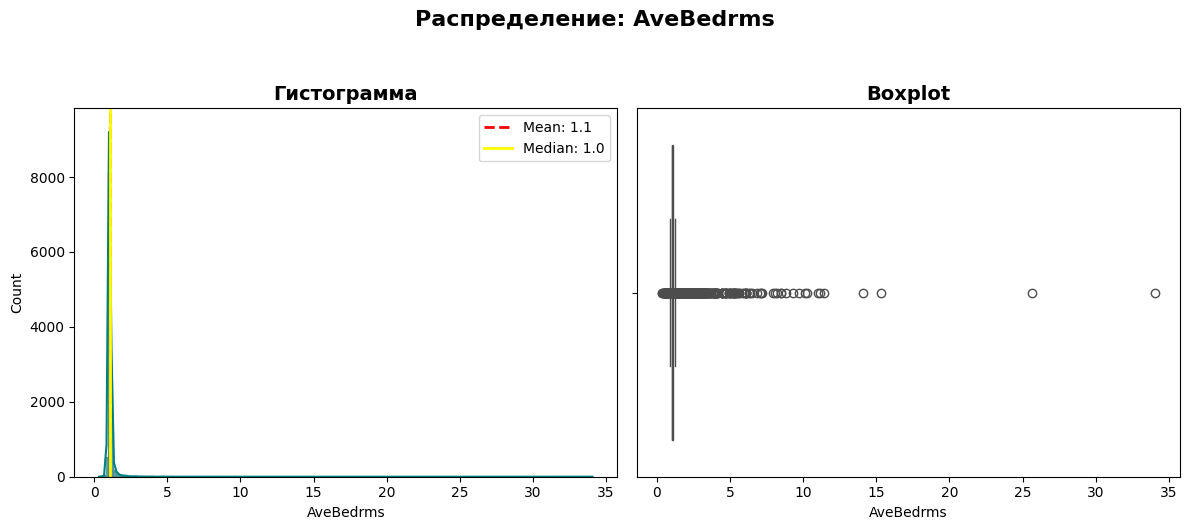

--- МЕТРИКИ ДЛЯ AVEBEDRMS ---
Skewness (Скос): 31.3170 (Идеал = 0.0)
Kurtosis (Острота пика): 1636.7120 (Идеал = 0.0)
⚠️ Вердикт: Сильный перекос
------------------------------


In [235]:
diagnose_distribution(df, 'AveBedrms')

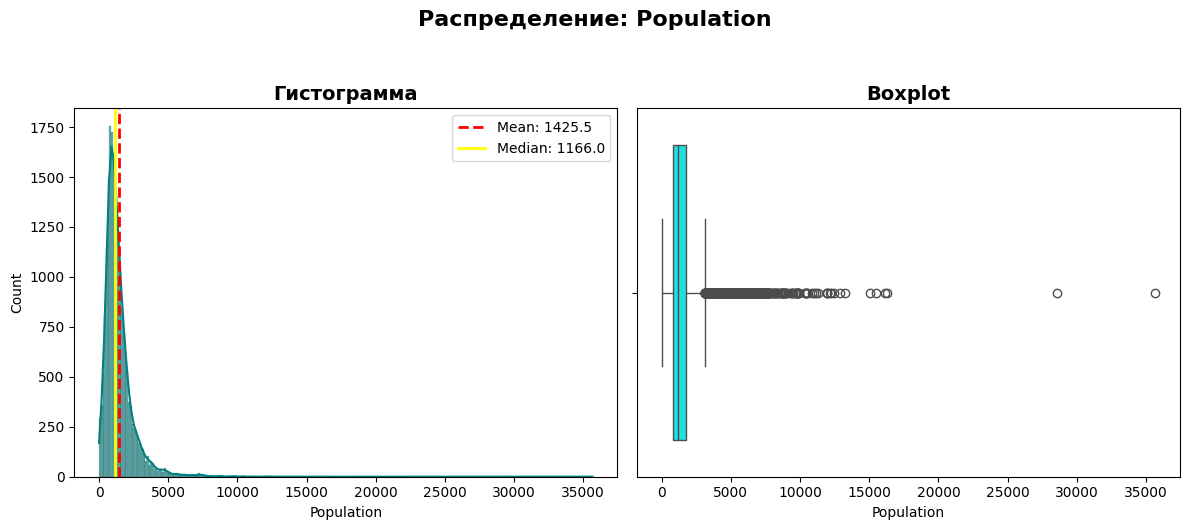

--- МЕТРИКИ ДЛЯ POPULATION ---
Skewness (Скос): 4.9359 (Идеал = 0.0)
Kurtosis (Острота пика): 73.5531 (Идеал = 0.0)
⚠️ Вердикт: Сильный перекос
------------------------------


In [236]:
diagnose_distribution(df, 'Population')

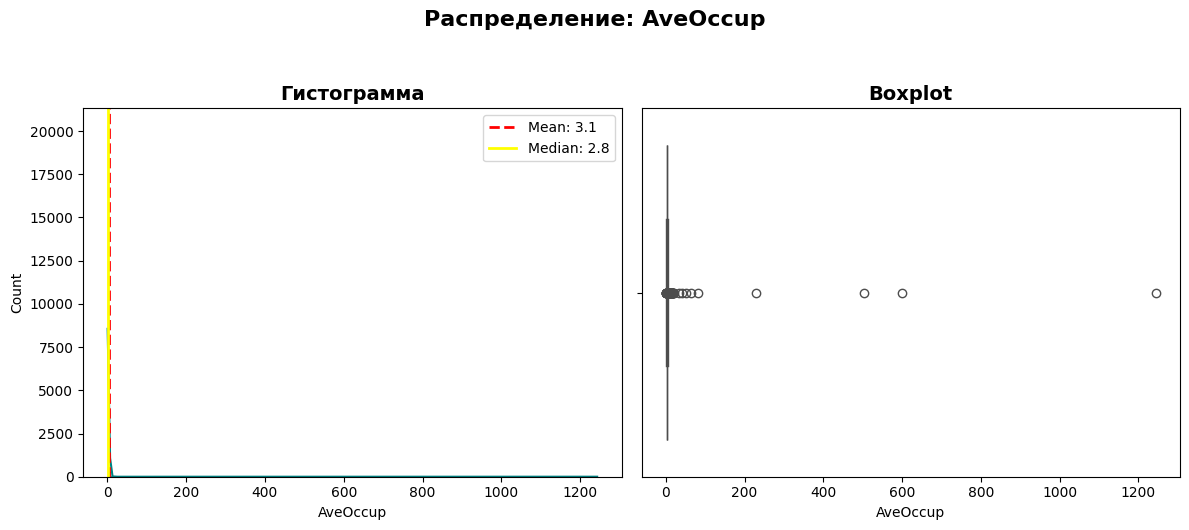

--- МЕТРИКИ ДЛЯ AVEOCCUP ---
Skewness (Скос): 97.6396 (Идеал = 0.0)
Kurtosis (Острота пика): 10651.0106 (Идеал = 0.0)
⚠️ Вердикт: Сильный перекос
------------------------------


In [237]:
diagnose_distribution(df, 'AveOccup')

1. Считаю нет смысла проверять широту и долготу на распределение данных, так как это координаты
2. К переменным, которые имеют большое плечо с одной стороны и большое количество в значений в одной куче применим логарифм

### **7. Логарифмирование переменных и построение модели**

In [238]:
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [239]:
df3 = df.copy()

In [240]:
df3['AveRooms'] = np.log(df3['AveRooms'])
df3['AveBedrms'] = np.log(df3['AveBedrms'])
df3['Population'] = np.log(df3['Population'])
df3['AveOccup'] = np.log(df3['AveOccup'])

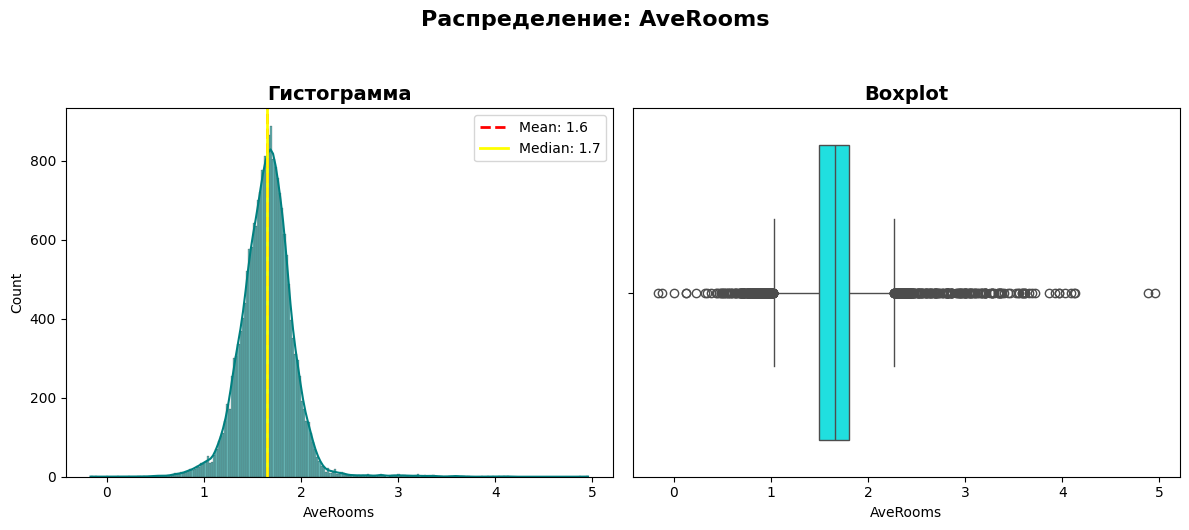

--- МЕТРИКИ ДЛЯ AVEROOMS ---
Skewness (Скос): 0.8681 (Идеал = 0.0)
Kurtosis (Острота пика): 8.9006 (Идеал = 0.0)
ℹ️ Вердикт: Умеренный перекос.
------------------------------


In [241]:
diagnose_distribution(df3, 'AveRooms')

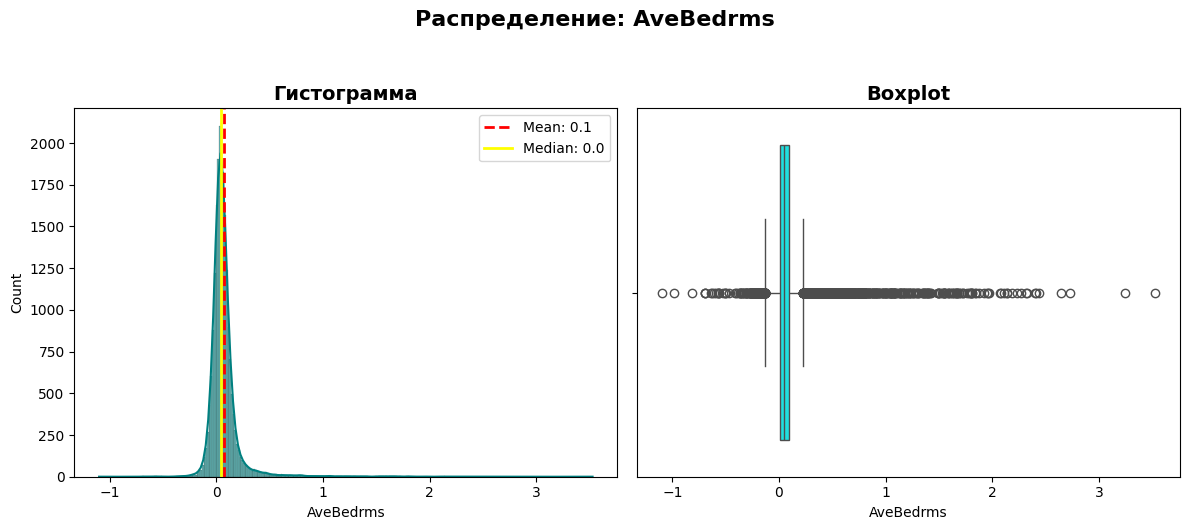

--- МЕТРИКИ ДЛЯ AVEBEDRMS ---
Skewness (Скос): 6.4060 (Идеал = 0.0)
Kurtosis (Острота пика): 69.9756 (Идеал = 0.0)
⚠️ Вердикт: Сильный перекос
------------------------------


In [242]:
diagnose_distribution(df3, 'AveBedrms')

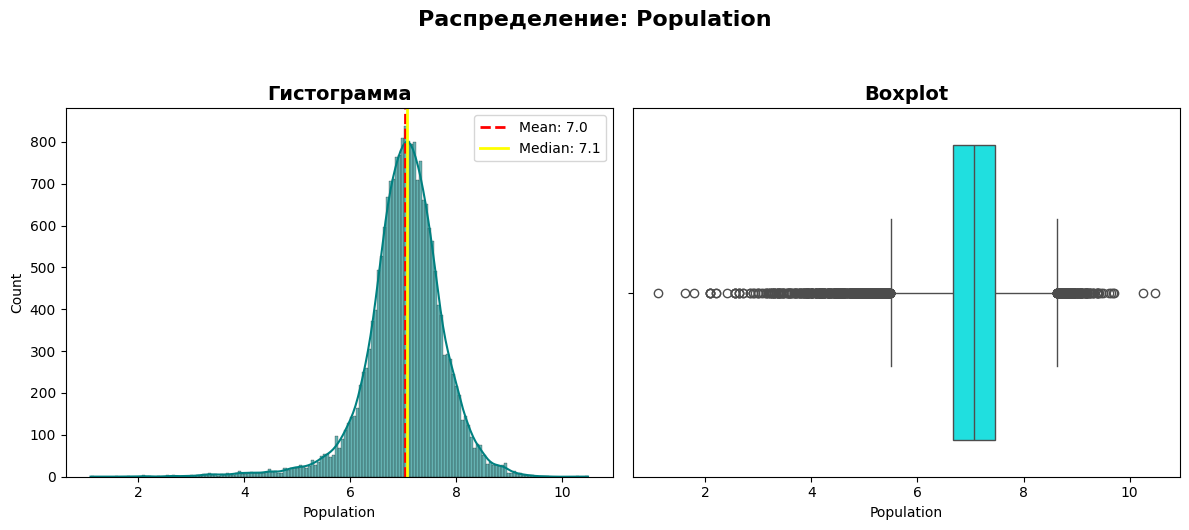

--- МЕТРИКИ ДЛЯ POPULATION ---
Skewness (Скос): -1.0708 (Идеал = 0.0)
Kurtosis (Острота пика): 4.6702 (Идеал = 0.0)
⚠️ Вердикт: Сильный перекос
------------------------------


In [243]:
diagnose_distribution(df3, 'Population')

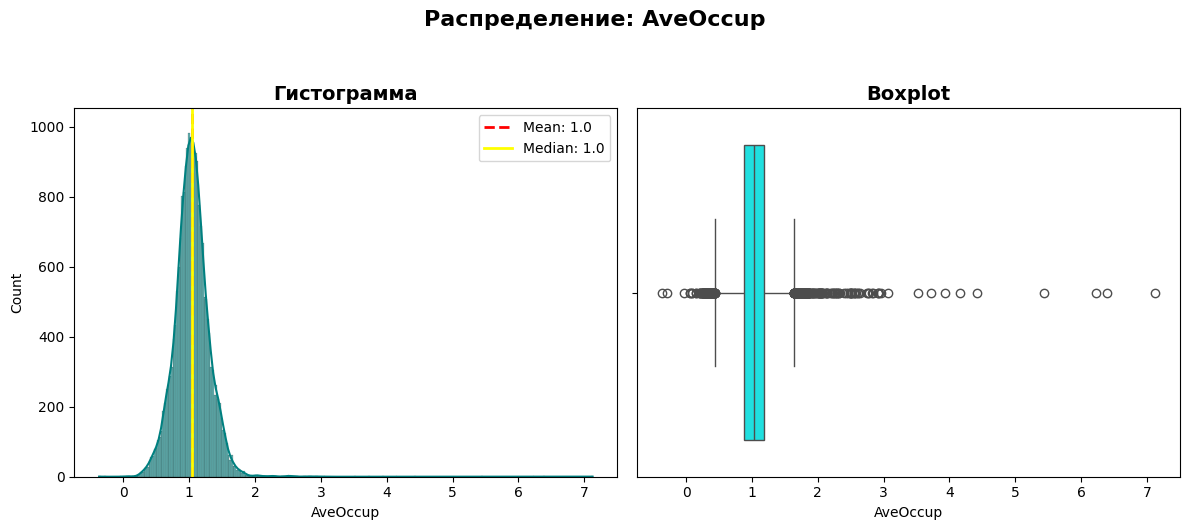

--- МЕТРИКИ ДЛЯ AVEOCCUP ---
Skewness (Скос): 2.1276 (Идеал = 0.0)
Kurtosis (Острота пика): 34.6343 (Идеал = 0.0)
⚠️ Вердикт: Сильный перекос
------------------------------


In [244]:
diagnose_distribution(df3, 'AveOccup')

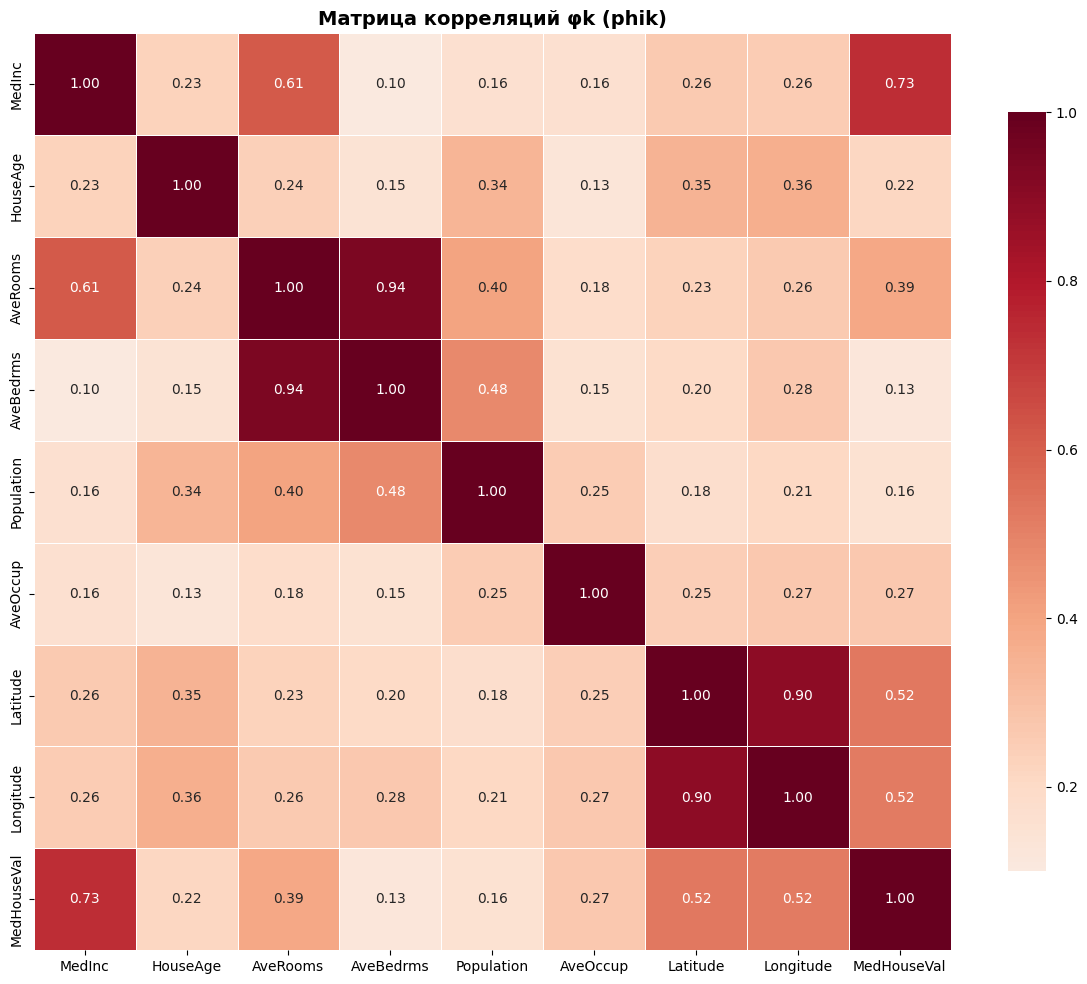

In [245]:
# Определяем интервальные (непрерывные) переменные
interval_cols = ['MedInc',
    'HouseAge',
    'AveRooms',
    'AveBedrms',
    'Population',
    'AveOccup',
    'Latitude',
    'Longitude',
    'MedHouseVal'
    ]

# Расчёт матрицы phik с явным указанием интервальных переменных
phik_matrix = df3.phik_matrix(interval_cols=interval_cols, )

# Heatmap
fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(phik_matrix, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            square=True, linewidths=0.5, ax=ax, cbar_kws={'shrink': 0.8})
ax.set_title('Матрица корреляций φk (phik)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

Построили заново матрицу корреляции, но уже с прологарифмированными данными. Видим увеличилась корреляция с AveRooms, AveBedrms, Population, AveOccup

In [260]:
X3 = df3[['MedInc','HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']]

In [261]:
y3 = df3['MedHouseVal']

In [262]:
X3_train, X3_test, y3_train, y3_test = train_test_split(X3, y3, test_size=0.2, random_state=42)

In [263]:
model3 = LinearRegression()
model3.fit(X3_train, y3_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](8,)","[ 0.44, 0.01,-0.61,...,-0.96,-0.41,-0.41]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](8,)","['MedInc','HouseAge','AveRooms',...,'AveOccup','Latitude','Longitude']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-32.73
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,8
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,8


In [264]:
y3_train_pred = model3.predict(X3_train)

In [265]:
y3_test_pred = model3.predict(X3_test)

In [266]:
print("ОБУЧАЮЩАЯ ВЫБОРКА (Train):")
print(f"  RMSE: {np.sqrt(mean_squared_error(y3_train, y3_train_pred))}")
print(f"  R²:   {r2_score(y3_train, y3_train_pred)}")
print(f"  MSE:  {mean_squared_error(y3_train, y3_train_pred):.4f}")
print("ТЕСТОВАЯ ВЫБОРКА (Train):")
print(f"  RMSE: {np.sqrt(mean_squared_error(y3_test, y3_test_pred))}")
print(f"  R²:   {r2_score(y3_test, y3_test_pred)}")
print(f"  MSE:  {mean_squared_error(y3_test, y3_test_pred):.4f}")

ОБУЧАЮЩАЯ ВЫБОРКА (Train):
  RMSE: 0.6671384605519033
  R²:   0.6670549223331652
  MSE:  0.4451
ТЕСТОВАЯ ВЫБОРКА (Train):
  RMSE: 0.6775404048826835
  R²:   0.6496811240832334
  MSE:  0.4591


In [268]:

print("Оценка модели №1 без изменения данных (Train):")
print(f"  RMSE: {np.sqrt(mean_squared_error(y_test, y_test_pred))}")
print(f"  R²:   {r2_score(y_test, y_test_pred)}")
print(f"  MSE:  {mean_squared_error(y_test, y_test_pred):.4f}")
print("Оценка модели №2 после построения матрциы и удаленяи колонок (Train):")
print(f"  RMSE: {np.sqrt(mean_squared_error(y2_test, y2_test_pred))}")
print(f"  R²:   {r2_score(y2_test, y2_test_pred)}")
print(f"  MSE:  {mean_squared_error(y2_test, y2_test_pred):.4f}")
print("Оценка модели №3 после логирифмирования данных (Train):")
print(f"  RMSE: {np.sqrt(mean_squared_error(y3_test, y3_test_pred))}")
print(f"  R²:   {r2_score(y3_test, y3_test_pred)}")
print(f"  MSE:  {mean_squared_error(y3_test, y3_test_pred):.4f}")

Оценка модели №1 без изменения данных (Train):
  RMSE: 0.7455813830127763
  R²:   0.575787706032451
  MSE:  0.5559
Оценка модели №2 после построения матрциы и удаленяи колонок (Train):
  RMSE: 0.7409322235939553
  R²:   0.5810616616067165
  MSE:  0.5490
Оценка модели №3 после логирифмирования данных (Train):
  RMSE: 0.6775404048826835
  R²:   0.6496811240832334
  MSE:  0.4591


У третьей модели увеличился R² и она является лучшей из трёх. 